## **Understanding the Basics for Ensemble Methods**



## **Learning objectives**

By the end of this notebook, you should be able to:
- Understand different ensemble methods and apply one using the `scikit-learn` library.
- Understand combining multiple models for enhanced predictions.

## **Overview**

### **Understanding ensemble learning**

Ensemble learning is a machine learning paradigm where **multiple models** (often called "weak learners") **are trained to solve the same problem and combined to get better results**. The main principle behind ensemble learning is that a group of weak learners can come together to form a strong learner, thereby increasing the accuracy of predictions. Ensemble methods can be especially powerful in reducing variance, bias, or improving predictions over single-model approaches.

### **Types of ensemble methods**
There are several ensemble methods, each with its unique way of combining models. The most common types include:

- **Bagging (bootstrap aggregating)**: It involves training multiple models in parallel, each on a random subset of the data (with replacement), and then averaging their predictions. **Random forest** is a popular example of bagging.

- **Boosting**: It trains models sequentially, each trying to correct its predecessor's errors. The models are weighted based on their accuracy, and predictions are made based on the weighted sum of the predictions. Examples include **AdaBoost**, **Gradient boosting**, and **XGBoost**.

- **Stacking (stacked generalisation)**: It involves training multiple models on the same data and then training a meta-model to make a final prediction based on the predictions of the previous models.

- **Voting**: In voting, multiple models are trained independently, and their predictions are combined through a majority vote (in classification problems) or an average (in regression problems) to make the final prediction. This method leverages the diversity among the models to improve the overall performance.

It's important to note that these are not the only ensemble methods available. Other, perhaps less commonly used, ensemble techniques exist that are not covered within the scope of this lesson. These methods further explore different strategies for model combination to improve prediction accuracy.

#### **Examples: Implementing an ensemble method using `scikit-learn`**
Let's implement a basic ensemble method using the `scikit-learn` library. We'll use the dataset provided to predict the `BiodiversityHealthIndex` using both a single model and an ensemble method for comparison. For the ensemble, we'll use a `RandomForestRegressor`, a popular bagging method.

#### **Step 1: Preparing the data**
We'll start by preparing our data for modelling. This involves splitting the data into features (`X`) and the target (`y`) and then splitting these into training and testing sets.

In [44]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [45]:
 # Load the dataset
data = pd.read_csv("https://cdn.alx-ai-tools.com/marimo/v2/data/SDG_15_Life_on_Land_Dataset.csv")

# Define features and target
X = data.drop('BiodiversityHealthIndex', axis=1)
y = data['BiodiversityHealthIndex']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **Building Individuals Model**

In [46]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Initialise and train the decision tree
tree = DecisionTreeRegressor(random_state=42, max_depth=3)
tree.fit(X_train, y_train)

# Predict and evaluate
tree_predictions = tree.predict(X_test)
tree_mse = mean_squared_error(y_test, tree_predictions)
print(f"Decision Tree MSE: {tree_mse}")

Decision Tree MSE: 0.08696874034772017


### **Ensemble Models**

In [47]:
from sklearn.ensemble import RandomForestRegressor

# Initialise and train the random forest
forest_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=3)
forest_model.fit(X_train, y_train)

# Predict and evaluate
forest_predictions = forest_model.predict(X_test)
forest_mse = mean_squared_error(y_test, forest_predictions)
print(f"Random Forest MSE: {forest_mse}")

Random Forest MSE: 0.08583054197782213


#### **Conclusion**
By comparing the mean squared error (MSE) of the decision tree model with that of the random forest, we can observe the impact of using ensemble methods. Note that we used a `max_depth=3` parameter in both the decision tree and random forest models, to ensure we're seeing the impact of using ensembles. Typically, the random forest (an ensemble method) should outperform the single decision tree due to its ability to reduce overfitting and variance in predictions. Limiting the max_depth parameter prevents overfitting the data, which could lead to individual trees being rather complex and elaborate.

### **Question**

If you had to pick between a homogeneous ensemble and a heterogeneous ensemble for a new classification problem, what factors would guide your choice?

### **Factors guiding the choice**

* **Model performance:** Heterogeneous ensembles can capture different patterns by combining different algorithms.
* **Data complexity:** Complex/non-linear data may benefit from diverse models.
* **Stability:** Homogeneous ensembles like Random Forest are often more stable and easier to tune.
* **Interpretability:** Homogeneous ensembles are generally easier to understand and manage.
* **Computational cost:** Heterogeneous ensembles can require more resources and tuning.
* **Baseline results:** Start with a strong homogeneous ensemble; move to heterogeneous methods if combining different models provides meaningful improvement.

> **Rule of thumb:** Choose **homogeneous** for simplicity, stability, and efficiency; choose **heterogeneous** when model diversity can significantly improve predictive performance.


### **Ensemble learning**

Ensemble learning in machine learning is the practice of **combining multiple models** to try and achieve higher overall model performance.

Ensembles can consist of multiple models trained on the same dataset. Each of these models is used to make predictions on the same input, then these predictions are aggregated across all models in some way (for example, by taking the mean) to produce the final output.

Other than the possibility of improving model performance, there are [lots of other reasons](https://towardsdatascience.com/simple-guide-for-ensemble-learning-methods-d87cc68705a2) why we might want to build an ensemble.

## 1. **Training the individual models**

Let's start by training different individual machine learning models on the same data.

We'll train a `linear regression`, a `decision tree`, and an `SVR` (i.e. [support vector machine regression](https://www.saedsayad.com/support_vector_machine_reg.htm) – *we'll explore this model in greater detail in later tutorials*)  model.

In [48]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns   

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

In [49]:
df = pd.read_csv("../data/house_price.csv")
df.head()

,LotArea,SalePrice
0,138,1204000
1,145,1274000
2,152,1673000
3,152,1232000
4,152,1195600


In [50]:
X = df["LotArea"] # Independent variable
y = df["SalePrice"] # Dependent variable


In [51]:
from plot import style_plot

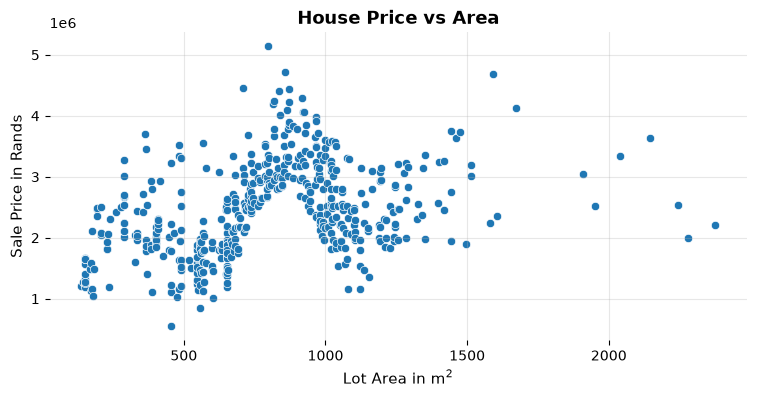

In [52]:
fig, ax = plt.subplots(figsize = (9, 4))

sns.scatterplot(x = X, y = y, ax = ax)


style_plot(
    ax,
    title = "House Price vs Area",
    xlabel = "Lot Area in m$^2$",
    ylabel = "Sale Price in Rands",
    grid = True
)
plt.show()

#### **Pre-processing**

Next we scale and split our dataset into training and testing sets so that we can later evaluate the performance of the model.

### (a) **Linear regression**

Create and fit the model:

In [53]:
# Convert X to 2D if it is a Series
X = X.to_frame() if isinstance(X, pd.Series) else X

# Convert y to 2D for scaling
y = y.to_numpy().reshape(-1, 1)

# Initialise scalers
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Scale
X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)

# Split together
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_scaled,
    test_size=0.2,
    random_state=6
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

# Fit model
lr = LinearRegression()
lr.fit(X_train, y_train.ravel())

X_train: (400, 1)
y_train: (400, 1)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.39]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.001271
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[19.81]


Check the model performance

RMSE: 0.9597285404528205


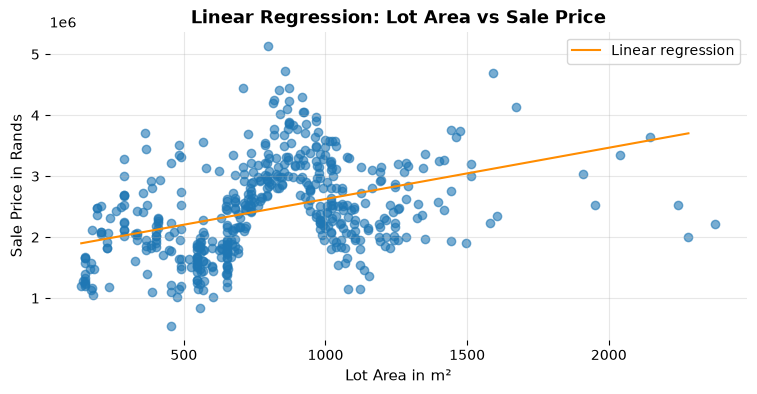

In [54]:
# Predict
y_pred = lr.predict(X_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

# Regression line
x_domain = np.linspace(
    X_train.min(),
    X_train.max(),
    100
).reshape(-1, 1)

y_domain = lr.predict(x_domain).reshape(-1, 1)

# Inverse transform
x_rescaled = x_scaler.inverse_transform(x_domain)
y_rescaled = y_scaler.inverse_transform(y_domain)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(X, y, alpha=0.6)
ax.plot(
    x_rescaled,
    y_rescaled,
    color = "darkorange",
    label="Linear regression"
)

style_plot(
    ax,
    title="Linear Regression: Lot Area vs Sale Price",
    xlabel="Lot Area in m²",
    ylabel="Sale Price in Rands",
    grid=True
)

ax.legend()
plt.show()

### **Decision Tree**

In [55]:
# Instantiate regression tree model
tree = DecisionTreeRegressor(max_depth=3)

tree.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes m

RMSE: 0.8155834161717601


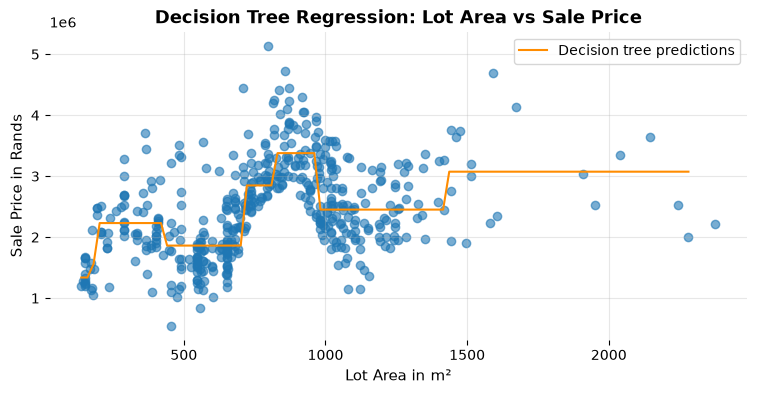

In [56]:
# Predict on test data
y_pred = tree.predict(X_test)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

# Create prediction domain in scaled X space
x_domain = np.linspace(
    X_train.min(),
    X_train.max(),
    100
).reshape(-1, 1)

# Predict
y_domain = tree.predict(x_domain).reshape(-1, 1)

# Convert back to original scale
x_rescaled = x_scaler.inverse_transform(x_domain)
y_rescaled = y_scaler.inverse_transform(y_domain)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(X, y, alpha=0.6)

ax.plot(
    x_rescaled,
    y_rescaled,
    color="darkorange",
    label="Decision tree predictions"
)

style_plot(
    ax,
    title="Decision Tree Regression: Lot Area vs Sale Price",
    xlabel="Lot Area in m²",
    ylabel="Sale Price in Rands",
    grid=True
)

ax.legend()
plt.show()

### **Support Vector Regression**

In [57]:
from sklearn.svm import SVR

RMSE: 0.8211319807999837


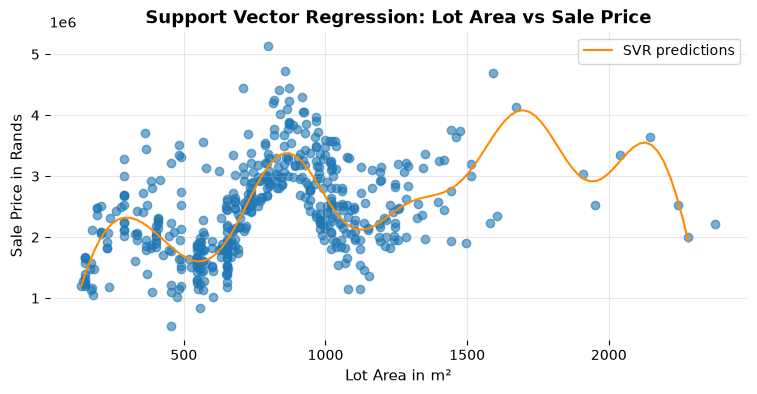

In [58]:
# Create and fit SVR model
svr = SVR(kernel="rbf", C=100, epsilon=0.1)

svr.fit(X_train, y_train.ravel())

# Predict on test data
y_pred = svr.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

# Create prediction domain
x_domain = np.linspace(
    X_train.min(),
    X_train.max(),
    100
).reshape(-1, 1)

# Predict across domain
y_domain = svr.predict(x_domain).reshape(-1, 1)

# Transform back to original scale
x_rescaled = x_scaler.inverse_transform(x_domain)
y_rescaled = y_scaler.inverse_transform(y_domain)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(X, y, alpha=0.6)

ax.plot(
    x_rescaled,
    y_rescaled,
    color="darkorange",
    label="SVR predictions"
)

style_plot(
    ax,
    title="Support Vector Regression: Lot Area vs Sale Price",
    xlabel="Lot Area in m²",
    ylabel="Sale Price in Rands",
    grid=True
)

ax.legend()
plt.show()

SVR is particularly useful here because the RBF kernel can capture non-linear relationships between LotArea and SalePrice, unlike ordinary linear regression.

## 2. **Heterogeneous ensembling in Python**

### (a) **Voting**

Voting involves combining individual model outputs through a kind of "[majority rule](https://en.wikipedia.org/wiki/Majority_rule)" paradigm.

This process of prediction aggregation varies in the context of regression and classification tasks:
- **Regression** – we take the **average** or **weighted average** of all predictions.
- **Classification** – we use the **mode** of all predictions (i.e. most frequently occurring prediction).

Within the code below, we instantiate, train, and evaluate such a voting ensemble using `sklearn`'s `VotingRegressor` class.

In [59]:
from sklearn.ensemble import VotingRegressor

In [60]:
# Define base models
models = [
    ("LR", lr),
    ("DT", tree),
    ("SVR", svr)
]

# Assign weights
model_weightings = np.array([0.1, 0.3, 0.6])

# Create Voting Regressor
v_reg = VotingRegressor(
    estimators=models,
    weights=model_weightings
)

# Fit ensemble
v_reg.fit(X_train, y_train.ravel())

# Predict
y_pred = v_reg.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Voting Regressor RMSE:", rmse)

Voting Regressor RMSE: 0.7763743784351236


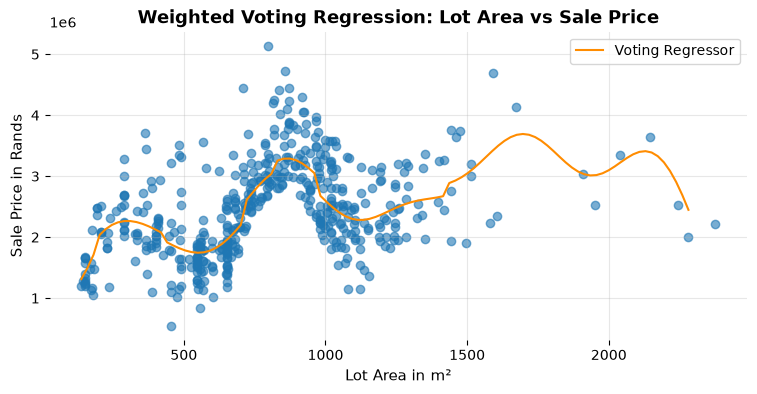

In [63]:
# Create prediction domain
x_domain = np.linspace(
    X_train.min(),
    X_train.max(),
    100
).reshape(-1, 1)

# Predict
y_domain = v_reg.predict(x_domain).reshape(-1, 1)

# Transform back to original scale
x_rescaled = x_scaler.inverse_transform(x_domain)
y_rescaled = y_scaler.inverse_transform(y_domain)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(X, y, alpha=0.6)

ax.plot(
    x_rescaled,
    y_rescaled,
    color="darkorange",
    label="Voting Regressor"
)

style_plot(
    ax,
    title="Weighted Voting Regression: Lot Area vs Sale Price",
    xlabel="Lot Area in m²",
    ylabel="Sale Price in Rands",
    grid=True
)

ax.legend()
plt.show()

**Interpretation**

Your weights mean:

* **LR:** 10%
* **Decision Tree:** 30%
* **SVR:** 60%

So the ensemble gives the greatest influence to SVR.

__Important:__ The weights should ideally be based on validation performance rather than chosen arbitrarily. A model with better predictive performance should generally receive greater weight.

### (b) **Stacking**

While we hope that you enjoyed playing around with the voting weights in the previous section, you may have found the overall exercise frustrating due to the difficulty of knowing how your choice of weightings would affect the ensemble's performance. As such, a natural question may have crossed your intelligent mind:

>What is a principled way of choosing the optimal voting weights for this ensemble?

If we take a step back, we can see that this question can actually be framed as another machine learning problem! After all, this entire time we have been looking at models that can accurately weight various variables in order to map them to an appropriate output.

So what stops us from weighting the outputs of multiple base models with that of another model?

In [64]:
from sklearn.ensemble import StackingRegressor

In [65]:
# Base models
models = [
    ("LR", lr),
    ("DT", tree),
    ("SVR", svr)
]

# Meta-learner
meta_learner_reg = LinearRegression()

# Stacking ensemble
s_reg = StackingRegressor(
    estimators=models,
    final_estimator=meta_learner_reg
)

# Fit
s_reg.fit(X_train, y_train.ravel())

# Predict
y_pred = s_reg.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Stacking Regressor RMSE:", rmse)

Stacking Regressor RMSE: 0.7786633768317541


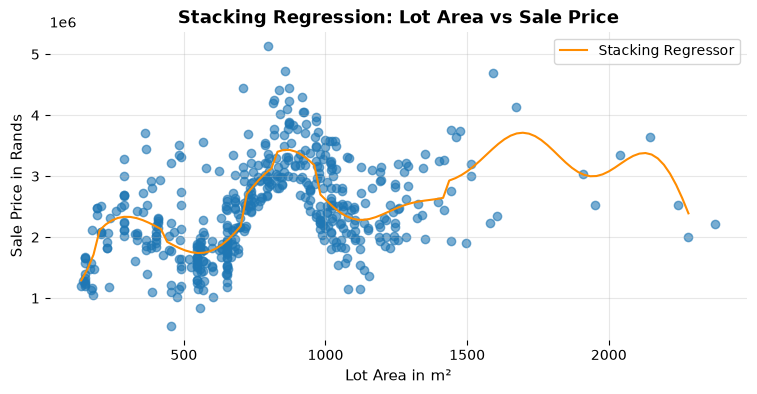

In [67]:
# Prediction domain
x_domain = np.linspace(
    X_train.min(),
    X_train.max(),
    100
).reshape(-1, 1)

# Predictions
y_domain = s_reg.predict(x_domain).reshape(-1, 1)

# Convert back to original scale
x_rescaled = x_scaler.inverse_transform(x_domain)
y_rescaled = y_scaler.inverse_transform(y_domain)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(X, y, alpha=0.6)

ax.plot(
    x_rescaled,
    y_rescaled,
    color="darkorange",
    label="Stacking Regressor"
)

style_plot(
    ax,
    title="Stacking Regression: Lot Area vs Sale Price",
    xlabel="Lot Area in m²",
    ylabel="Sale Price in Rands",
    grid=True
)

ax.legend()
plt.show()

__Key difference from Voting__

* **Voting:** You manually specify how much influence each model gets.

* **Stacking:** The meta-learner learns how to combine the predictions of LR, DT, and SVR.

> For your analysis, compare the RMSE of Linear Regression, Decision Tree, SVR, Voting, and Stacking. The model with the lowest test RMSE provides the best predictive performance on unseen data.

__Question__

> A colleague says stacking is always better than voting because it's more complex. Do you agree? What trade-off are they ignoring?

No. **Stacking is not always better than voting.**

* **Stacking:** More flexible because a meta-model learns how to combine predictions.
* **Voting:** Simpler, faster, and less prone to overfitting.
* **Trade-off:** Stacking adds **complexity, computational cost, and overfitting risk**.

> **Key point:** More complexity does not guarantee better performance. Choose based on **validation/test performance**, not complexity.


## **Bagging and Boosting**

__Bagging__

In [68]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=7, random_state=42),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train.ravel())

bag_pred = bagging.predict(X_test)

print("Bagging RMSE:",
      np.sqrt(mean_squared_error(y_test, bag_pred)))

Bagging RMSE: 0.7967324458923497


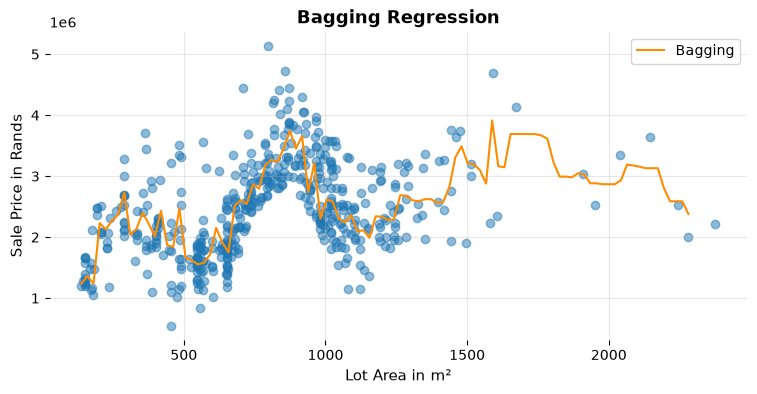

In [73]:
# Bagging predictions
x_domain = np.linspace(
    X_train.min(),
    X_train.max(),
    100
).reshape(-1, 1)

bag_y_pred = bagging.predict(x_domain).reshape(-1, 1)

x_rescaled = x_scaler.inverse_transform(x_domain)
bag_y_rescaled = y_scaler.inverse_transform(bag_y_pred)

fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(X, y, alpha=0.5)
ax.plot(
    x_rescaled,
    bag_y_rescaled,
    color="darkorange",
    label="Bagging"
)

style_plot(
    ax,
    title="Bagging Regression",
    xlabel="Lot Area in m²",
    ylabel="Sale Price in Rands",
    grid=True
)

ax.legend()
plt.show()

__Boosting__

In [70]:
from sklearn.ensemble import GradientBoostingRegressor

boosting = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

boosting.fit(X_train, y_train.ravel())

boost_pred = boosting.predict(X_test)

print("Boosting RMSE:",
      np.sqrt(mean_squared_error(y_test, boost_pred)))

Boosting RMSE: 0.767565063686627


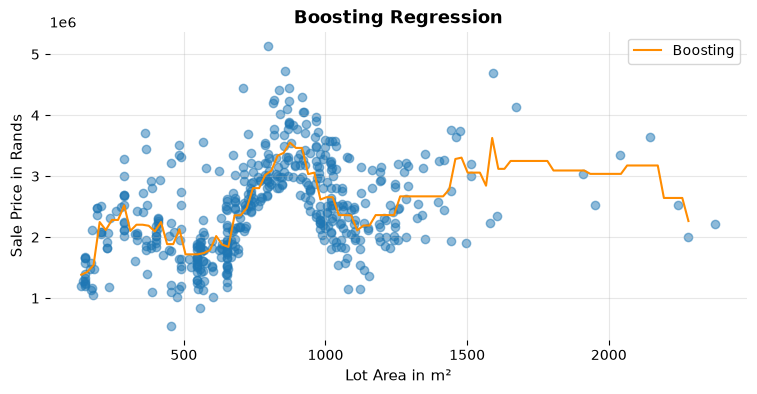

In [75]:
# Boosting predictions
boost_y_pred = boosting.predict(x_domain).reshape(-1, 1)

boost_y_rescaled = y_scaler.inverse_transform(boost_y_pred)

fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(X, y, alpha=0.5)
ax.plot(
    x_rescaled,
    boost_y_rescaled,
    color="darkorange",
    label="Boosting"
)

style_plot(
    ax,
    title="Boosting Regression",
    xlabel="Lot Area in m²",
    ylabel="Sale Price in Rands",
    grid=True
)

ax.legend()
plt.show()

In [71]:
print("Bagging RMSE:", 
      np.sqrt(mean_squared_error(y_test, bag_pred)))

print("Boosting RMSE:", 
      np.sqrt(mean_squared_error(y_test, boost_pred)))

Bagging RMSE: 0.7967324458923497
Boosting RMSE: 0.767565063686627


* **Bagging** builds trees independently and mainly reduces variance.
* **Boosting** builds trees sequentially, with each tree correcting previous errors, mainly reducing bias.

__Question__

> When deciding between implementing a homogeneous bagging ensemble (like Random Forest) or a heterogeneous stacking ensemble (combining KNN, Random Forest, and Linear Models) in a production environment, what critical operational trade-off must a software engineer consider?

__Answer__

> Stacking ensembles can achieve higher accuracy by blending distinct algorithmic perspectives, but they introduce significant architectural complexity, longer training times, and reduced interpretability compared to homogeneous bagging.

__Question__

> A machine learning engineer evaluates a dataset using a single standalone decision tree baseline versus a scikit-learn Gradient Boosting model. They observe the following results on the test set:
- Single Decision Tree Baseline: Accuracy = 74%, Variance = High
- Gradient Boosting Ensemble (150 trees): Accuracy = 88%, Variance = Low
What core architectural mechanism explains why the boosting ensemble significantly outperforms the single baseline model?

__Answer__

> Boosting operates sequentially; each new base model is explicitly trained to correct the residual errors made by the combination of the preceding models, incrementally driving down bias and improving robustness.

__Question__

> Consider a scenario where you train a Decision Tree, a Support Vector Machine (SVM), and a Logistic Regression model on the same customer churn dataset. Instead of picking the single best-performing model, you combine their outputs into a single system using a meta-model that learns how to optimally weight their individual predictions. What type of machine learning architecture does this describe?

__Answer__

> A heterogeneous stacking ensemble.



__Question__

> The Random Forest algorithm relies heavily on a homogeneous ensemble strategy called bagging (Bootstrap Aggregating). How does bagging use bootstrapping to create structural diversity among its identical base models and improve overall prediction robustness?

__Answer__

> It repeatedly resamples the training dataset with replacement, generating unique variations of the data for each individual base model to train on, which reduces overall variance.

__Question__

> A data scientist is selecting a machine learning strategy for a dataset with highly non-linear, unpredictable relationships and no clear underlying distribution. They are deciding between a parametric method (like Linear Regression) and a non-parametric method (like a Decision Tree or a K-Nearest Neighbors ensemble). Which statement correctly distinguishes these two approaches and identifies the right fit?

__Answer__

> Parametric methods use a fixed number of parameters to define a pre-determined functional form (like a straight line), whereas non-parametric methods do not assume a rigid structure, allowing them to flexibly fit complex, arbitrary data distributions.